# Notebook 02: Regression Model

**Student Name:** [Joseph Villa]

**Dataset:** [Cleaned Dataset]

**Target Variable:** [CKD Stage]

**Checkpoint 3 Due:** Feb 15

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Good data scientists don't just run code—they communicate their findings clearly. Take time to write thoughtful, complete responses to all reflection prompts. This demonstrates your understanding and prepares you for real-world stakeholder communication.

---

## Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Sklearn - evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [2]:
# Load cleaned data from previous notebook
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (5000, 12)


,Creatinine,BUN,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,CKD Stage,Elderly_Indicator,Comorbidity_Count,BUN_Creatinine_Ratio
0,0.788803,8.386869,1632.649387,0,0,27.682074,106.700203,1.570370,1,0,0,10.632398
1,3.413970,53.688796,935.540516,1,0,33.122208,410.008362,3.425287,3,0,1,15.726207
2,0.647645,7.466540,1774.553846,1,1,55.832284,123.336925,1.123301,2,0,2,11.528756
3,0.795508,12.516821,2360.602980,0,0,32.391900,116.098870,3.086846,1,0,0,15.734373
4,0.869010,19.855960,1987.750901,0,1,66.689515,55.668760,2.174980,2,1,1,22.848941


In [4]:
# Define your target variable
TARGET = 'CKD Stage'  # <-- UPDATE THIS!

print(f"Target: {TARGET}")
print(f"\nTarget statistics:")
print(df[TARGET].describe())

# Store target range for later interpretation
target_range = df[TARGET].max() - df[TARGET].min()
target_std = df[TARGET].std()
print(f"\nTarget range: {target_range:,.2f}")
print(f"Target std: {target_std:,.2f}")

Target: CKD Stage

Target statistics:
count    5000.000000
mean        2.073200
std         1.359489
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: CKD Stage, dtype: float64

Target range: 4.00
Target std: 1.36


## Section 2: Prepare Features and Target

In [5]:
# Separate features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAll features ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (5000, 11)
Target shape: (5000,)

All features (11):
['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'Elderly_Indicator', 'Comorbidity_Count', 'BUN_Creatinine_Ratio']


In [6]:
# Check for any non-numeric columns that need to be handled
non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numeric:
    print(f"Warning: Non-numeric columns found: {non_numeric}")
    print("You need to encode these or go back to Notebook 01!")
else:
    print("All features are numeric. Ready to proceed!")

All features are numeric. Ready to proceed!


## Section 3: Train-Test Split

Split your data into training and test sets. The training set is used to train the model, and the test set is used to evaluate how well it generalizes to unseen data.

In [7]:
# TODO: Split your data into training and test sets
# 
# Requirements:
# - Use an 80/20 split (test_size=0.2)
# - Set random_state=42 for reproducibility
# - Store results in: X_train, X_test, y_train, y_test
#
# Hint: Use train_test_split(X, y, ...)

# YOUR CODE HERE:

# Import the function that perfoms the splits

from sklearn.model_selection import train_test_split

# Split features X and the target Y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Quick check to confirm sizes
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (4000, 11) X_test: (1000, 11)
y_train: (4000,) y_test: (1000,)


In [8]:
# Verify your split (run this cell to check)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set: 4,000 samples (80%)
Test set: 1,000 samples (20%)


## Section 4: Feature Scaling

Many ML algorithms perform better when features are on similar scales. StandardScaler transforms features to have mean=0 and std=1.

**Important:** Fit the scaler on training data only, then transform both train and test. This prevents data leakage.

In [9]:
# TODO: Scale your features using StandardScaler
#
# Steps:
# 1. Create a StandardScaler instance
# 2. Fit the scaler on X_train and transform X_train (use fit_transform)
# 3. Transform X_test using the same scaler (use transform only - NOT fit_transform!)
# 4. Store results in: X_train_scaled, X_test_scaled
#
# Why fit only on train? To prevent "data leakage" - test data should be truly unseen.

# YOUR CODE HERE:

# I referred a lot to the regression practice lesson you provided during this unit to help with the following with some google.

from sklearn.preprocessing import StandardScaler

# 1. Create scaler per instruction
scaler = StandardScaler()

# 2. Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform test data using same scaler you advised on
X_test_scaled = scaler.transform(X_test)

# 4. Quick shape check
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (4000, 11)
Scaled X_test shape: (1000, 11)


In [10]:
# Convert back to DataFrame for easier viewing (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verify scaling worked
print("Features scaled successfully!")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std().mean():.4f}")

Features scaled successfully!

Scaled feature means (should be ~0): -0.0000
Scaled feature stds (should be ~1): 1.0001


## Section 5: Baseline Model

Start with a simple Linear Regression to establish a baseline performance. This gives us a reference point for improvement.

In [11]:
# This helper function evaluates any model - you'll use it throughout this notebook
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    }
    
    return results, model, y_test_pred

In [12]:
# TODO: Create and evaluate a baseline Linear Regression model
#
# Steps:
# 1. Create a LinearRegression() model instance
# 2. Use the evaluate_model() function to train and evaluate it
# 3. Store the results
#
# The evaluate_model function returns: (results_dict, trained_model, predictions)

# YOUR CODE HERE:

# Create Linear Regression model 
baseline_model = LinearRegression()

# Train and evaluate using helper function
baseline_results, baseline_trained, baseline_preds = evaluate_model(
    baseline_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Linear Regression"
)

# Display results from the model above
baseline_results


{'Model': 'Linear Regression',
 'Train R2': 0.9411979473767642,
 'Test R2': 0.9419429474367025,
 'Train RMSE': np.float64(0.32940820434113166),
 'Test RMSE': np.float64(0.32813717109336005),
 'Train MAE': 0.2753037484785175,
 'Test MAE': 0.27427534700137335}

In [13]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Linear Regression")
print("=" * 50)
print(f"Train R²: {baseline_results['Train R2']:.4f}")
print(f"Test R²:  {baseline_results['Test R2']:.4f}")
print(f"Test RMSE: {baseline_results['Test RMSE']:,.2f}")
print(f"Test MAE: {baseline_results['Test MAE']:,.2f}")

# Context for RMSE
print(f"\n--- RMSE in Context ---")
print(f"RMSE as % of target range: {baseline_results['Test RMSE']/target_range*100:.1f}%")
print(f"RMSE as % of target std: {baseline_results['Test RMSE']/target_std*100:.1f}%")

BASELINE MODEL: Linear Regression
Train R²: 0.9412
Test R²:  0.9419
Test RMSE: 0.33
Test MAE: 0.27

--- RMSE in Context ---
RMSE as % of target range: 8.2%
RMSE as % of target std: 24.1%


### Baseline Interpretation

*Analyze your baseline results:*

**Understanding your metrics:**
- **R² (0 to 1)**: How much variance in target is explained by features. 0.7+ is often considered good.
- **RMSE**: Average prediction error in the same units as your target. Lower is better.
- **RMSE as % of range**: Helps you understand if errors are big or small relative to your data.

**Questions to answer:**
- What does your R² score tell you about how well features explain the target?
- Is there a big gap between train and test R²? (Gap > 0.1 could indicate overfitting)
- Is your RMSE reasonable? (e.g., if predicting house prices, is a $20K error acceptable?)

**Your interpretation:**

[The baseline model has an R² of about 0.94, which means the features explain around 94% of the changes in CKD Stage. The train and test R² scores are almost the same, so the model does not appear to be overfitting. The RMSE is about 0.33, which means the predictions are usually off by less than half a stage which is not bad. Since CKD Stage ranges from 1 to 5, that seems like a small and reasonable error, but I want to get your thoughts on this because you have experience in the Health Industry. Do they require it to be strong like this since it's not like predicting stock prices. At first, the results seemed almost too good, but it makes sense because CKD Stage is closely related to lab values like Creatinin, BUN, etc. Since those measurements are used to determine kidney function, it is reasonable that they strongly predict the stage. Still, it would be smart to double-check that there is no data leakage, just to be safe. Overall, the results look strong and clinically reasonable.]

## Section 6: Model Iteration

Try at least 2-3 different models to see if you can improve on the baseline.

In [14]:
# Store all results for comparison
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Linear Regression (Baseline)': baseline_trained
}

### Model 2: Ridge Regression

Ridge adds L2 regularization to prevent overfitting by penalizing large coefficients.

In [15]:
# TODO: Create and evaluate a Ridge Regression model
#
# Create a Ridge model with alpha=1.0
# Use evaluate_model() to train and evaluate
# Add results to all_results list
# Add trained model to trained_models dict

# YOUR CODE HERE:

# Ensuring it's imported before going further
from sklearn.linear_model import Ridge

# Create Ridge model per instructions above 
ridge_model = Ridge(alpha=1.0)

# Train and evaluate
ridge_results, ridge_trained, ridge_preds = evaluate_model(
    ridge_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Ridge Regression"
)

# Store the results
all_results.append(ridge_results)
trained_models["Ridge Regression"] = ridge_trained

# Print results
print(f"Ridge Regression - Test R²: {ridge_results['Test R2']:.4f}, Test RMSE: {ridge_results['Test RMSE']:,.2f}")

Ridge Regression - Test R²: 0.9419, Test RMSE: 0.33


### Model 3: Lasso Regression

Lasso adds L1 regularization, which can zero out unimportant features (automatic feature selection).

In [16]:
# TODO: Create and evaluate a Lasso Regression model
#
# Create a Lasso model with alpha=0.1
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:

# Create the Lasso model per your instructions above
lasso_model = Lasso(alpha=0.1, random_state=42)

# Train and evaluate using the helper function
lasso_results, lasso_trained, lasso_preds = evaluate_model(
    lasso_model,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    model_name="Lasso Regression"
)

# Store results so I can compare later when comparing models
all_results.append(lasso_results)
trained_models["Lasso Regression"] = lasso_trained

# Print results
print(f"Lasso Regression - Test R²: {lasso_results['Test R2']:.4f}, Test RMSE: {lasso_results['Test RMSE']:,.2f}")

# Show which features Lasso kept (non-zero coefficients)
lasso_coefs = pd.Series(lasso_trained.coef_, index=X.columns)
kept_features = lasso_coefs[lasso_coefs != 0]
print(f"\nLasso kept {len(kept_features)} of {len(X.columns)} features")

Lasso Regression - Test R²: 0.9248, Test RMSE: 0.37

Lasso kept 5 of 11 features


### Model 4: Decision Tree

In [17]:
# TODO: Create and evaluate a Decision Tree model
#
# Create a DecisionTreeRegressor with max_depth=10 and random_state=42
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:

# Create the model  per above instructions
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Train and evaluate using the same helper function as the other models / Google help me with this, especially the scaled note below
dt_results, dt_trained, dt_preds = evaluate_model(
    dt_model,
    X_train_scaled, X_test_scaled,   # using the scaled features for consistency
    y_train, y_test,
    model_name="Decision Tree"
)

# Save results so you I compare later
all_results.append(dt_results)
trained_models["Decision Tree"] = dt_trained

# Print results
print(f"Decision Tree - Test R²: {dt_results['Test R2']:.4f}, Test RMSE: {dt_results['Test RMSE']:,.2f}")

Decision Tree - Test R²: 0.9535, Test RMSE: 0.29


### Model 5: Random Forest

In [18]:
# TODO: Create and evaluate a Random Forest model
#
# Create a RandomForestRegressor with:
#   - n_estimators=100
#   - max_depth=10
#   - random_state=42
#   - n_jobs=-1 (use all CPU cores)
#
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:

# Create the Random Forest model from the instructions above
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train and evaluate the dataset
rf_results, rf_trained, rf_preds = evaluate_model(
    rf_model,
    X_train, X_test,   # Trees do NOT need scaling
    y_train, y_test,
    model_name="Random Forest"
)

# Store results for comparison to other models later
all_results.append(rf_results)
trained_models["Random Forest"] = rf_trained


# Print results
print(f"Random Forest - Test R²: {rf_results['Test R2']:.4f}, Test RMSE: {rf_results['Test RMSE']:,.2f}")

Random Forest - Test R²: 0.9772, Test RMSE: 0.21


### Add Your Own Model (Optional)

*Feel free to try additional models or tune hyperparameters!*

In [ ]:
# YOUR ADDITIONAL MODEL HERE:
# Try GradientBoostingRegressor, different hyperparameters, etc.



## Section 7: Cross-Validation (More Robust Evaluation)

Cross-validation gives us a more reliable estimate of model performance by testing on multiple different train/test splits.

In [19]:
# Perform 5-fold cross-validation on top models
print("5-Fold Cross-Validation Results:")
print("=" * 50)

cv_results = []

models_to_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}

for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_results.append({
        'Model': name,
        'CV Mean R²': scores.mean(),
        'CV Std R²': scores.std()
    })
    print(f"{name}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)

5-Fold Cross-Validation Results:
Linear Regression: R² = 0.9408 (+/- 0.0057)
Ridge: R² = 0.9408 (+/- 0.0057)
Random Forest: R² = 0.9754 (+/- 0.0028)


**Why Cross-Validation Matters:**
- A model that performs well on one train/test split might just be lucky
- CV tests on 5 different splits, giving us confidence in the results
- Lower standard deviation = more consistent/reliable model

## Section 8: Model Comparison

In [20]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test R2', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
4,Random Forest,0.9953,0.9772,0.0931,0.2057,0.0439,0.0985
3,Decision Tree,0.9964,0.9535,0.0819,0.2935,0.0134,0.0932
0,Linear Regression,0.9412,0.9419,0.3294,0.3281,0.2753,0.2743
1,Ridge Regression,0.9412,0.9419,0.3294,0.3281,0.2753,0.2743
2,Lasso Regression,0.9229,0.9248,0.3771,0.3735,0.3436,0.3396


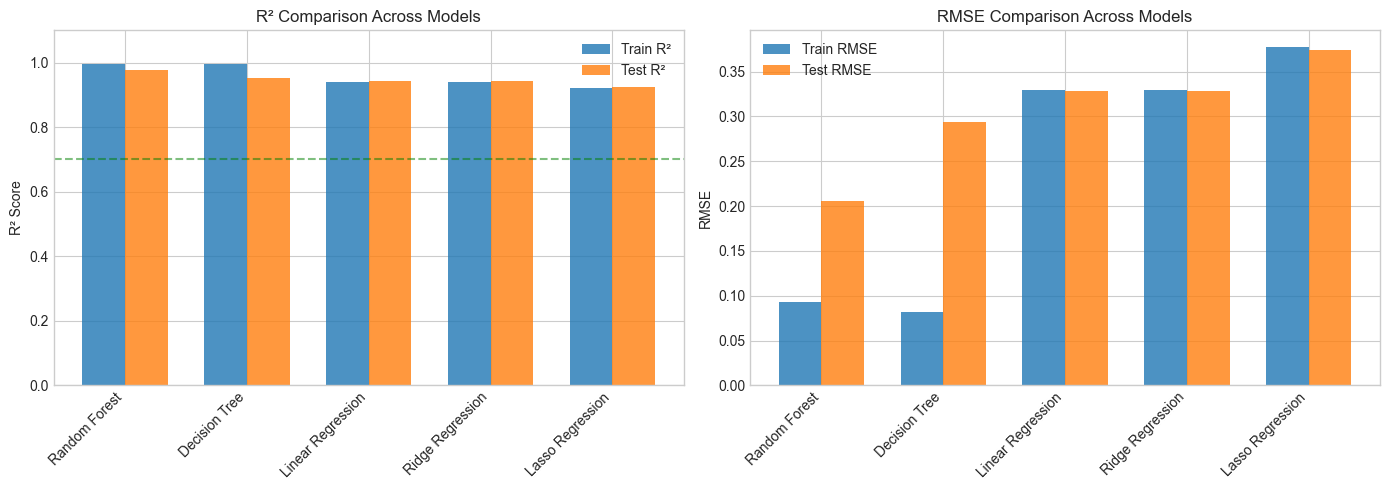

In [21]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Comparison
models = results_df['Model']
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, results_df['Train R2'], width, label='Train R²', alpha=0.8)
axes[0].bar(x + width/2, results_df['Test R2'], width, label='Test R²', alpha=0.8)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Comparison Across Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')

# RMSE Comparison
axes[1].bar(x - width/2, results_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[1].bar(x + width/2, results_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison Across Models')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

### Model Iteration Reflection

*Before selecting your best model, reflect on what you learned:*

**Questions to answer:**
- Which model improved most over the baseline?
- Did any models show signs of overfitting (big train vs test gap)?
- Did regularization (Ridge/Lasso) help or hurt performance?
- Did tree-based models (Decision Tree, Random Forest) work better than linear models?

**Your reflection:**

[The model that improved the most over the baseline was Random Forest from 0.94 (Linear Regression) to 0.98 and reduced RMSE, showing it captured patterns the linear models could not. However, is this nearly too perfect or is this okay for clincial data is my question? I would like to hear your input on this please. I did notice the Decision Tree showed some signs of overfitting because it's train r2 was very high compared to the test r2. However, Random Forest reduced that gap, suggesting ensemble averaging helped improve generalization. Regularization did not improve performance much. Lasso reduced the number of features but slight hurt performance, raised the question of whether the dropped features still carry meaningful clinical information. I actually wanted to ask on this, I wanted to see what features it kept or dropped, I google that code, but was not sure if that was okay to put back after that section to check. However, I didn't want to mess with the steps in this project, but I am very curious on that. Tree-based models clearly worked better than linear models, which suggests the relationship between kidney function variables and CKD Stage is likely non-linear. However, since CKD Stage is clinically defined using lab thresholds, I should consider whether the model is partially learning rules that already directly determine the stage. That could explain why performance is so high and may be something worth discussing further.]

## Section 9: Feature Importance & Selection

**Important:** Your final model should use only **4-8 features**. This section helps you identify which features matter most.

Feature Importance (Random Forest):
                 Feature  Importance
0             Creatinine    0.900919
5                    Age    0.031681
1                    BUN    0.027469
9      Comorbidity_Count    0.025766
6       Protein_in_Urine    0.005894
10  BUN_Creatinine_Ratio    0.003803
7           Water_Intake    0.001617
2           Urine_Output    0.001612
3               Diabetes    0.000614
4           Hypertension    0.000474
8      Elderly_Indicator    0.000151


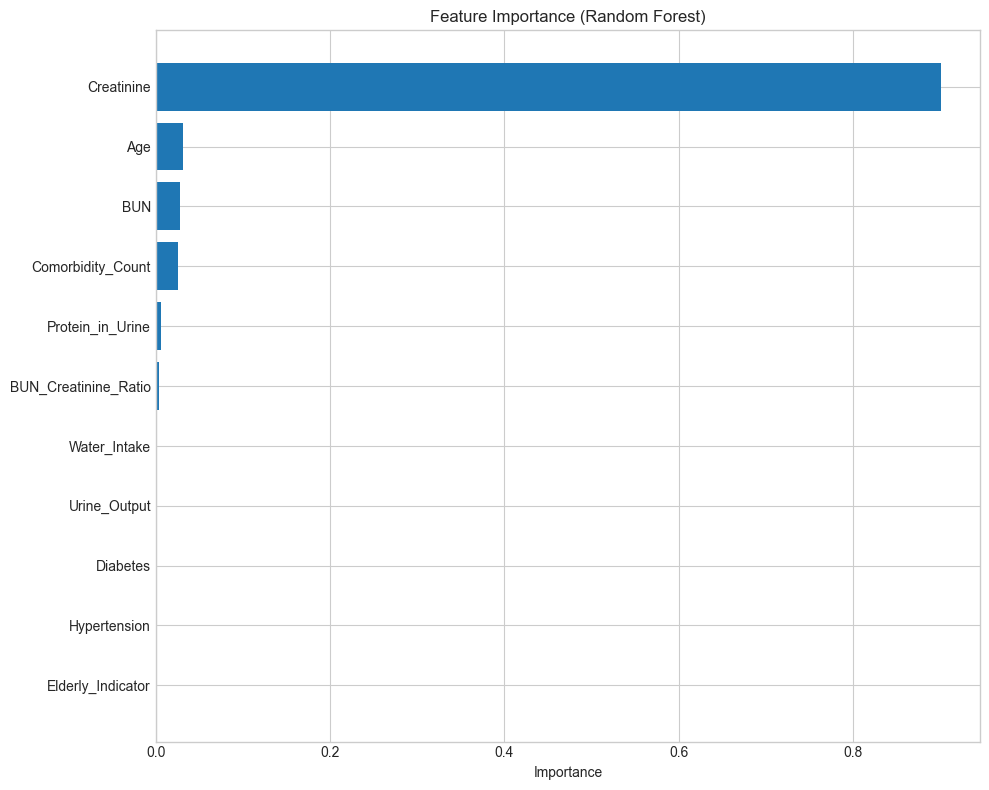

In [22]:
# Get feature importance from Random Forest (works well for this)
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_trained.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(rf_importance)

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'][::-1], rf_importance['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

In [23]:
# Also check correlations with target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Absolute Correlations with Target:")
print(correlations)

Absolute Correlations with Target:
Creatinine              0.935002
BUN                     0.826800
Urine_Output            0.776181
Protein_in_Urine        0.765820
Comorbidity_Count       0.171667
Hypertension            0.128169
Age                     0.117810
Diabetes                0.112927
Elderly_Indicator       0.090085
Water_Intake            0.026438
BUN_Creatinine_Ratio    0.000687
dtype: float64


In [24]:
# TODO: Select your top features (4-8 features)
#
# Based on the importance analysis above, choose your best features.
# Consider both Random Forest importance AND correlations.
# Also think about what makes sense from a domain perspective.

SELECTED_FEATURES = [
    'Creatinine',
    'BUN',
    'Protein_in_Urine',
    'Urine_Output',
    'Age',
    'Comorbidity_Count'
]

# Fallback if you haven't selected yet
if len(SELECTED_FEATURES) == 0:
    SELECTED_FEATURES = rf_importance['Feature'].head(6).tolist()
    print(f"Using top 6 features from Random Forest: {SELECTED_FEATURES}")
else:
    print(f"Selected features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")

Selected features (6): ['Creatinine', 'BUN', 'Protein_in_Urine', 'Urine_Output', 'Age', 'Comorbidity_Count']


In [25]:
# Retrain with selected features only
X_train_selected = X_train_scaled[SELECTED_FEATURES]
X_test_selected = X_test_scaled[SELECTED_FEATURES]

print(f"Training with {len(SELECTED_FEATURES)} selected features...")

# Test a few models with selected features
selected_results = []

for name, model in [('Linear Regression', LinearRegression()),
                    ('Ridge', Ridge(alpha=1.0)),
                    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))]:
    results, trained, _ = evaluate_model(model, X_train_selected, X_test_selected, y_train, y_test, name)
    selected_results.append(results)
    print(f"{name} with {len(SELECTED_FEATURES)} features - Test R²: {results['Test R2']:.4f}")

selected_df = pd.DataFrame(selected_results)

Training with 6 selected features...
Linear Regression with 6 features - Test R²: 0.9413
Ridge with 6 features - Test R²: 0.9413
Random Forest with 6 features - Test R²: 0.9774


### Feature Selection Justification

**Questions to answer:**
- Which features did you select and why?
- Did performance drop significantly with fewer features?
- Do these features make sense from a domain perspective?
- These are the features users will input in your Streamlit app—are they reasonable to ask for?

**Your justification:**

[I selected Creatinine, BUN, Urine_Output, Protein_in_Urine, Age, and Comorbidity_Count because they had the strongest correlations with CKD Stage and also made clinical sense. Creatinine and BUN are directly tied to kidney function, while urine output and protein in urine reflect how well the kidneys are filtering. Age and comorbidities add important real-world risk context. When I reduced the number of features, performance did not drop much. Linear and Ridge stayed around 0.94 R², and Random Forest remained very high (~0.98). This shows these selected features capture most of the predictive signal. However, choosing the features really made me think—especially about Creatinine because the high importance it has. Since CKD Stage is largely determined by kidney function (like creatinine/GFR), including it may make the model almost “too good” because it is strongly tied to CKD stages. I do not think this is true data leakage like GFR was when I had to remove it, but it clearly has a very strong influence. Removing it could test whether the model can predict stage from supporting risk factors instead of the main lab driver. This is when I thought more from my own experience, I remember being told at Stage 5 with only 8% kidney function I did not immediately start dialysis as usual. That decision was not based on creatinine alone—it also depended on BUN and other lab values not being at critical levels. That makes me think using multiple labs together reflects real clinical reasoning.
From a domain perspective, these features make sense because they are common labs doctors already review. They would also be reasonable inputs for a Streamlit app, since users could realistically enter recent lab results and basic health information before the follow up doctor visit that is usually a few days up to weeks depending how bad or good the results are. Many people do not fully understand their stage without a doctor explaining the labs honestly, so this type of tool could help bridge that gap. Well, that's what I like to think, but please feel free to give me your thoughts!]

## Section 10: Best Model Selection

In [26]:
# TODO: Choose and train your final model with selected features
#
# Based on your analysis, pick the best model type and instantiate it.
# Consider: performance, consistency, simplicity
#
# Example: final_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# YOUR CODE HERE:
# final_model 

final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train on selected features
final_model.fit(X_train_selected, y_train)

print("Final model trained successfully!")



Final model trained successfully!


In [27]:
# Fit and evaluate final model
final_model.fit(X_train_selected, y_train)
y_pred = final_model.predict(X_test_selected)

# Final metrics
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Model: {type(final_model).__name__}")
print(f"Features: {SELECTED_FEATURES}")
print(f"\nTest R²: {final_r2:.4f}")
print(f"Test RMSE: {final_rmse:,.2f}")
print(f"Test MAE: {final_mae:,.2f}")
print(f"\nRMSE as % of target range: {final_rmse/target_range*100:.1f}%")

FINAL MODEL PERFORMANCE
Model: RandomForestRegressor
Features: ['Creatinine', 'BUN', 'Protein_in_Urine', 'Urine_Output', 'Age', 'Comorbidity_Count']

Test R²: 0.9774
Test RMSE: 0.20
Test MAE: 0.10

RMSE as % of target range: 5.1%


### Best Model Justification

*Explain why you chose this model as your best:*

**Questions to consider:**
- Why did you select this model over others?
- Is there significant overfitting (train vs test gap)?
- How does the performance compare to your baseline?
- Would a simpler model be almost as good?
- Does the RMSE represent acceptable prediction error for your problem?

**Your justification:**

[Random forest is the final model because it has the higest test r2 and the lowest RMSE. It performed better than the baseline, and stayed strong during cross-validation. There was no major overfitting since the train and test scores were close. The performance improved compared to the baseline from 0.94 to 0.98 r2 which is very good. The simple models was still good, but random forest reduced the prediction error even more. Since the RMSE is only about 0.2 of a stage, that error is very small in the CKD world and should be good for clinical prediction problems.]

## Section 11: Best Model Analysis

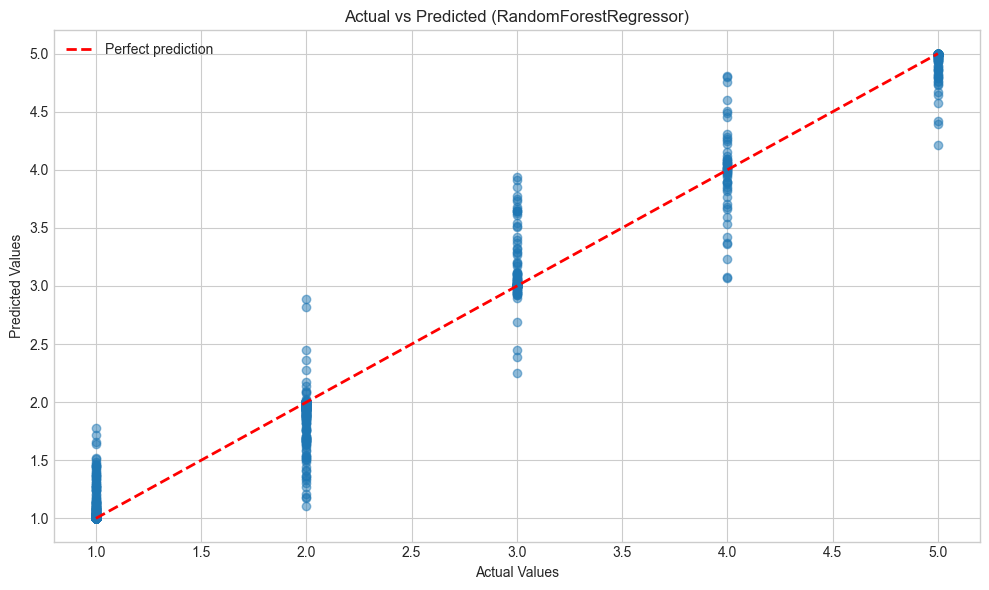

In [28]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted ({type(final_model).__name__})')
plt.legend()
plt.tight_layout()
plt.show()

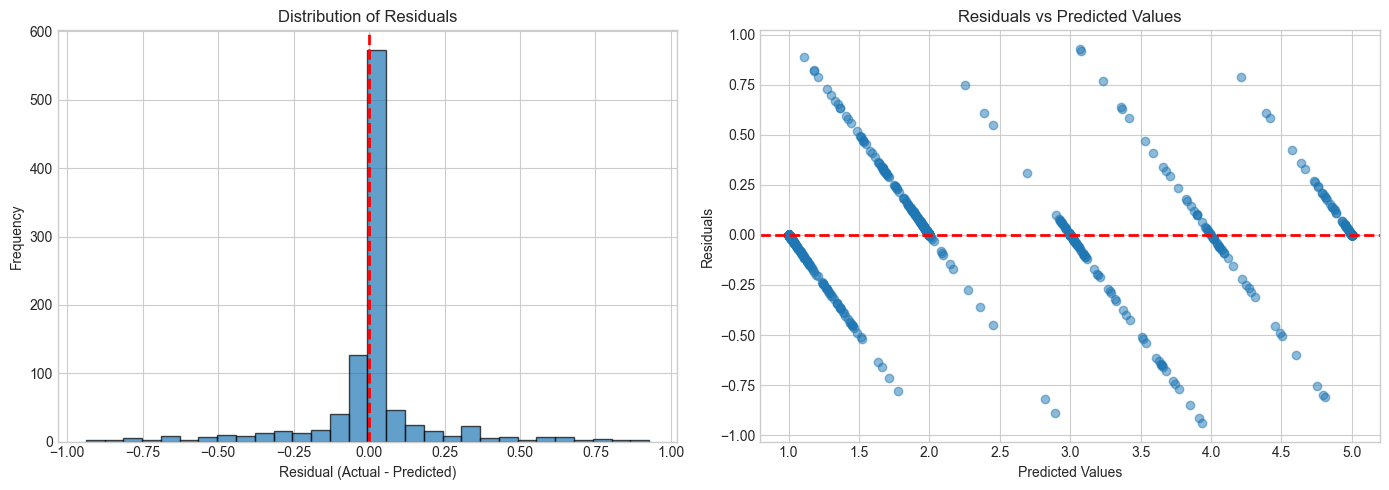

Residual mean (should be ~0): -0.00
Residual std: 0.20


In [29]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution (should be roughly normal, centered at 0)
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')

# Residuals vs Predicted (should show no pattern)
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.show()

print(f"Residual mean (should be ~0): {residuals.mean():.2f}")
print(f"Residual std: {residuals.std():,.2f}")

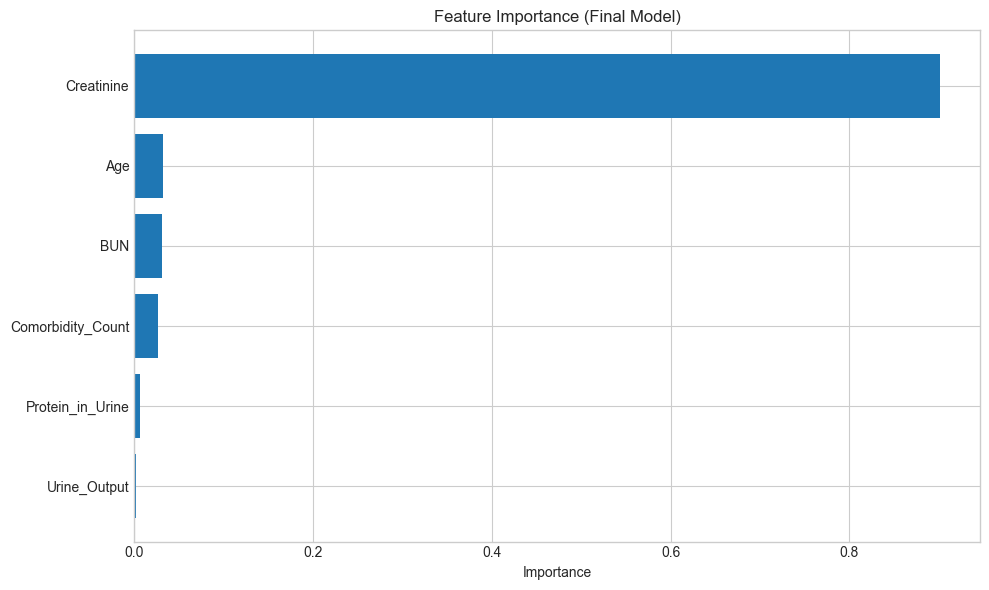

In [30]:
# Feature importance for final model (with selected features)
if hasattr(final_model, 'feature_importances_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(final_importance['Feature'], final_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance (Final Model)')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Coefficient': final_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in final_importance['Coefficient']]
    plt.barh(final_importance['Feature'], final_importance['Coefficient'], color=colors)
    plt.xlabel('Coefficient')
    plt.title('Feature Coefficients (Final Model)')
    plt.tight_layout()
    plt.show()

## Section 12: Save Model and Artifacts

In [31]:
# Create a new scaler fitted only on selected features
final_scaler = StandardScaler()
X_train_final = X_train[SELECTED_FEATURES]
final_scaler.fit(X_train_final)

# Save the best model
model_path = '../models/regression_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on selected features only)
scaler_path = '../models/regression_scaler.pkl'
joblib.dump(final_scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save feature names (the selected features for Streamlit app)
features_path = '../models/regression_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

Model saved to ../models/regression_model.pkl
Scaler saved to ../models/regression_scaler.pkl
Features saved to ../models/regression_features.pkl


In [32]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

# Test prediction
test_sample = X_test[loaded_features].iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)

print(f"\nModel verification:")
print(f"Features used: {loaded_features}")
print(f"Sample input: {test_sample.values[0]}")
print(f"Predicted: {test_pred[0]:,.2f}")
print(f"Actual: {y_test.iloc[0]:,.2f}")
print(f"\nModel saved and verified successfully!")


Model verification:
Features used: ['Creatinine', 'BUN', 'Protein_in_Urine', 'Urine_Output', 'Age', 'Comorbidity_Count']
Sample input: [1.15759476e+00 1.28835405e+01 1.07345866e+02 1.92351727e+03
 4.40997331e+01 0.00000000e+00]
Predicted: 1.01
Actual: 1.00

Model saved and verified successfully!


## Section 13: Binning Strategy for Classification

**IMPORTANT:** Before you start Notebook 03, you need to send your binning strategy to Abishek on Slack for approval by **Feb 15**.

### Analyze Target Distribution

In [33]:
# Look at target distribution to help decide binning
print(f"Target: {TARGET}")
print(f"\nDescriptive Statistics:")
print(y.describe())

print(f"\nPercentiles:")
for p in [10, 25, 33, 50, 67, 75, 90]:
    print(f"{p}th percentile: {y.quantile(p/100):,.2f}")

Target: CKD Stage

Descriptive Statistics:
count    5000.000000
mean        2.073200
std         1.359489
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: CKD Stage, dtype: float64

Percentiles:
10th percentile: 1.00
25th percentile: 1.00
33th percentile: 1.00
50th percentile: 2.00
67th percentile: 2.00
75th percentile: 3.00
90th percentile: 5.00


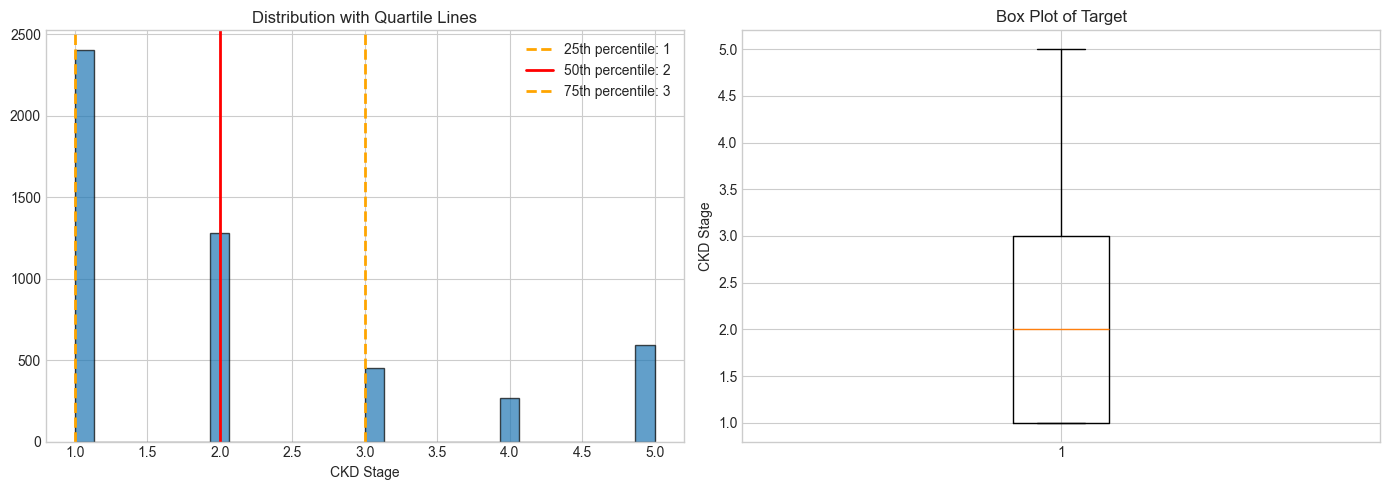

In [34]:
# Visualize potential binning strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with quartile lines
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7)
for p, color, style in [(25, 'orange', '--'), (50, 'red', '-'), (75, 'orange', '--')]:
    axes[0].axvline(y.quantile(p/100), color=color, linestyle=style, linewidth=2,
                     label=f'{p}th percentile: {y.quantile(p/100):,.0f}')
axes[0].set_xlabel(TARGET)
axes[0].set_title('Distribution with Quartile Lines')
axes[0].legend()

# Box plot
axes[1].boxplot(y)
axes[1].set_ylabel(TARGET)
axes[1].set_title('Box Plot of Target')

plt.tight_layout()
plt.show()

### Proposed Binning Strategy

*Complete this section and send to Abishek on Slack by Feb 15:*

**1. How many categories will you create?**

[I will create 3 categories: Early, Moderate, and Severe CKD.]

**2. What are your bin thresholds?**

[I was thinking of the thresholds to be Early CKD to be Stages 1-2, Moderate CKD Stage 3, & Severe CKD for Stage 4-5.]

**3. Why does this binning make sense for your problem?**

[This binning make sense because a lot of the patients data is more between Stages 1-3, with very little in Stages 4-5. Grouping the 3 categories reduces imbalance while keeping a strong clinical meaning. In reality, Stages 1-2 the doctors don't really suggest a lot of changes in reality. Stage 3 they would run tests, if you catch it early, but when you hit Stage 4 you have to start applying for a Kidney Transplant (that's when the insurance allows you to start the process ahead). I want to keep it still medically realistic.]

In [35]:
# Preview your binning
def create_bins_preview(y, strategy='quartile'):
    if strategy == 'quartile':
        bins = [y.min()-1, y.quantile(0.25), y.quantile(0.75), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    elif strategy == 'tertile':
        bins = [y.min()-1, y.quantile(0.33), y.quantile(0.67), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    # Add your custom strategy here if needed
    
    return pd.cut(y, bins=bins, labels=labels)

# Preview with quartile binning
y_binned = create_bins_preview(y, 'quartile')
print("Preview of binned target (using quartiles):")
print(y_binned.value_counts().sort_index())
print(f"\nPercentages:")
print((y_binned.value_counts(normalize=True) * 100).round(1).sort_index())

Preview of binned target (using quartiles):
CKD Stage
Low       2403
Medium    1736
High       861
Name: count, dtype: int64

Percentages:
CKD Stage
Low       48.1
Medium    34.7
High      17.2
Name: proportion, dtype: float64


---

## Summary

### What You Accomplished
- [ ] Loaded and prepared cleaned data
- [ ] Split data into train and test sets
- [ ] Scaled features appropriately
- [ ] Built a baseline model
- [ ] Tried multiple model types
- [ ] Performed cross-validation
- [ ] Selected top 4-8 features
- [ ] Compared and selected best model
- [ ] Analyzed model performance (residuals, feature importance)
- [ ] Saved model, scaler, and feature list
- [ ] Planned binning strategy for classification

### Key Results

**Best Model:** [Model name]

**Selected Features:** [List them]

**Test R²:** [Value]

**Test RMSE:** [Value]

**Improvement over baseline:** [Percentage or description]

---

---

## Checkpoint 3 Submission Instructions

**Congratulations!** You've completed Checkpoint 3 (Regression Model).

### Step 1: Save This Notebook
- File -> Save (or Ctrl+S / Cmd+S)

### Step 2: Send Binning Strategy to Abishek
- Message Abishek on Slack with your binning strategy
- Include: number of categories, thresholds, and justification

### Step 3: Commit to GitHub

```bash
# Stage your changes
git add notebooks/02_regression_model.ipynb
git add models/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 3: Regression model with feature selection"

# Push to GitHub
git push
```

### Step 4: Submit to Canvas
1. Go to the Checkpoint 3 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

1. **Wait for binning approval** from Abishek
2. Move on to **Notebook 03: Classification Model**

---